In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [ ]:

# Charger le dataset
df = pd.read_csv('../data/superstore.csv', encoding='latin-1')

print(df.head())

In [ ]:
# Analyse détaillée de la structure
print(f"Le dataset contient {df.shape[0]} lignes et {df.shape[1]} colonnes.")

print("\nTypes des colonnes :")
print(df.dtypes)

# Analyser les colonnes numériques vs catégorielles
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print(f"\nColonnes numériques : {list(numeric_cols)}")
print(f"Colonnes catégorielles : {list(cat_cols)}")

In [ ]:
# Conversion des dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Vérification
print(df[['Order Date', 'Ship Date']].dtypes)

In [ ]:
# Créer un dataframe pour visualiser le taux de données manquantes
missing_data = pd.DataFrame({'Total': df.isnull().sum(), 'Pourcentage': (df.isnull().sum()/df.shape[0])*100})
print(missing_data[missing_data['Total'] > 0].sort_values(by='Pourcentage', ascending=False))

print(f"Nombre total de lignes : {len(df)}")

Nombre de lignes dupliquées : 0


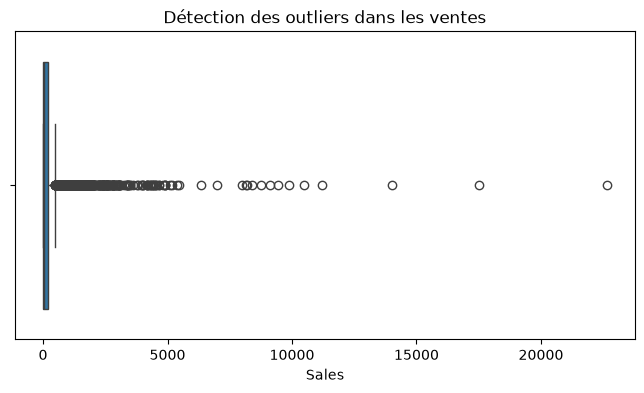

In [6]:
# Doublons
print(f"Nombre de lignes dupliquées : {df.duplicated().sum()}")

# Analyser les valeurs aberrantes (Outliers) sur une colonne comme 'Sales'
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Sales'])
plt.title("Détection des outliers dans les ventes")
plt.show()

Category
Office Supplies    0.602962
Furniture          0.212227
Technology         0.184811
Name: proportion, dtype: float64


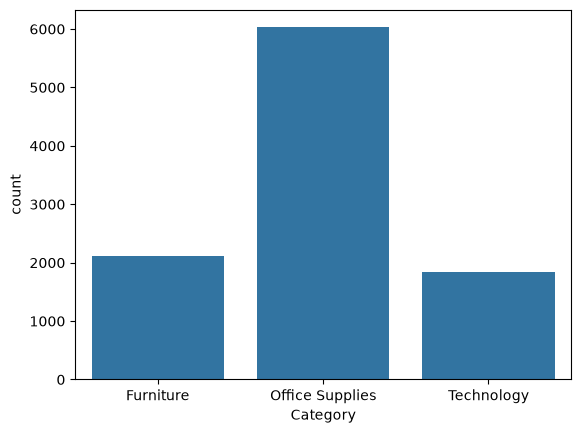

In [ ]:
# Analyse des variables cibles (Préparation ML)
print(df['Category'].value_counts(normalize=True))
sns.countplot(x='Category', data=df)
plt.show()

La distribution des catégories révèle une prédominance de la catégorie 'Office Supplies', qui représente environ 60% des transactions totales. Les catégories 'Furniture' et 'Technology' sont sous-représentées en comparaison.

Implication pour le modèle : Lors de l'entraînement du modèle de classification, il faudra être vigilant sur le déséquilibre des classes pour éviter un biais en faveur des 'Office Supplies'.

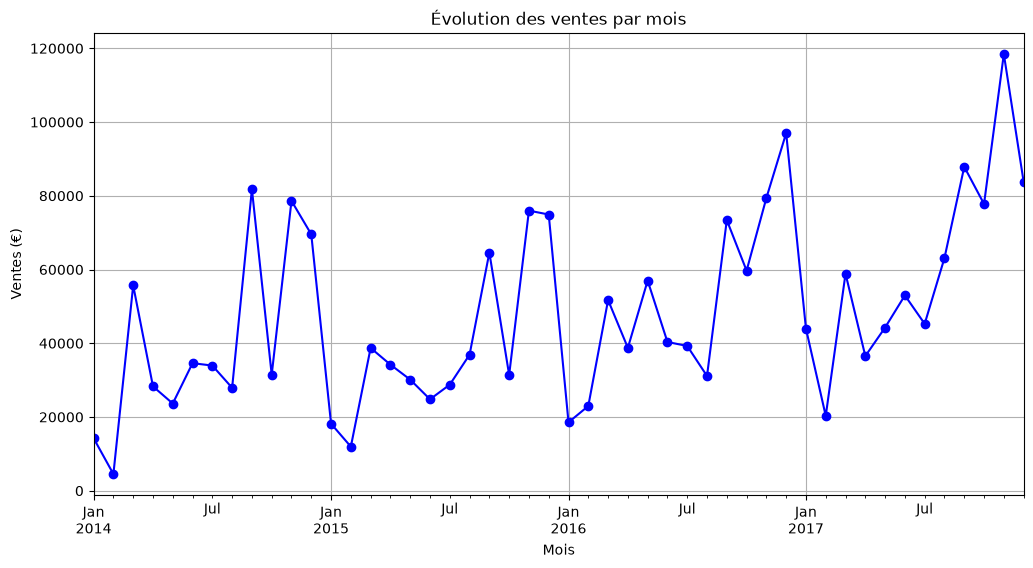

In [10]:
# Analyse temporelle

## nouvelle colonne 'Order Month' pour grouper par mois
df['Order Month'] = df['Order Date'].dt.to_period('M')

## Ventes mensuelles
monthly_sales = df.groupby('Order Month')['Sales'].sum()

## Affichage du graphique
plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='line', marker='o', color='b')
plt.title("Évolution des ventes par mois")
plt.xlabel("Mois")
plt.ylabel("Ventes (€)")
plt.grid(True)
plt.show()

L'analyse temporelle révèle une tendance de croissance annuelle soutenue. Nous observons une forte saisonnalité en fin d'année, suggérant une corrélation avec les périodes de fêtes. La forte volatilité observée sur certains mois suggère qu'une stratégie de gestion des stocks plus fine pourrait lisser les pics et les creux de revenus.

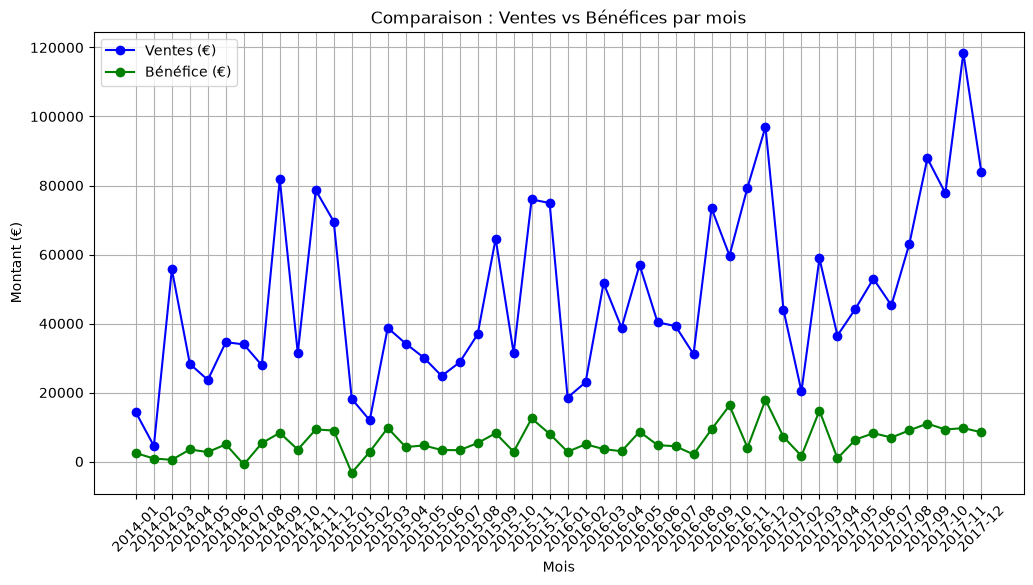

In [11]:
# Analyse de la rentabilité

## Données par mois pour le Profit et les Sales
monthly_data = df.groupby('Order Month')[['Sales', 'Profit']].sum()

## Création du graphique
plt.figure(figsize=(12, 6))
plt.plot(monthly_data.index.astype(str), monthly_data['Sales'], label='Ventes (€)', marker='o', color='blue')
plt.plot(monthly_data.index.astype(str), monthly_data['Profit'], label='Bénéfice (€)', marker='o', color='green')

plt.title("Comparaison : Ventes vs Bénéfices par mois")
plt.xlabel("Mois")
plt.ylabel("Montant (€)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

Bien que les ventes (courbe bleue) augmentent globalement sur la période, le bénéfice (courbe verte) reste relativement "plat" et bas.

Il y a un décalage critique entre le volume de ventes et la rentabilité.

Même lors des pics de ventes (fin d'année), le bénéfice n'augmente pas proportionnellement.

Cela suggère une stratégie de remises trop agressives. L'entreprise sacrifie ses marges pour générer du chiffre d'affaires.

Vous avez même des mois où le bénéfice est proche de zéro, voire négatif, malgré des ventes importantes. C'est un signal d'alerte majeur.

La croissance du chiffre d'affaires n'est pas corrélée à une croissance équivalente des bénéfices, ce qui pointe vers une problématique de gestion des marges que l'entreprise gagnerait à approfondir.

In [ ]:
# Modélisation prédictive

## Préparation des données pour le modèle
### 1. Créer la cible (Target) : 1 si profit > 0, sinon 0
df['Is_Profitable'] = (df['Profit'] > 0).astype(int)

### 2. Choix des variables prédictives (Features)
# Colonnes numériques utiles
features = ['Sales', 'Quantity', 'Discount']
X = df[features]
y = df['Is_Profitable']

### 3. Séparer en train/test (80% pour apprendre, 20% pour tester)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Entraînement du modèle
### Initialisation du modèle
model = RandomForestClassifier(n_estimators=100, random_state=42)

### Apprentissage
model.fit(X_train, y_train)

### Prédiction sur les données de test
y_pred = model.predict(X_test)

### Évaluation
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.81      0.84       377
           1       0.96      0.97      0.96      1622

    accuracy                           0.94      1999
   macro avg       0.92      0.89      0.90      1999
weighted avg       0.94      0.94      0.94      1999



Le modèle de classification par Random Forest atteint une précision globale de 94%. Le F1-score élevé (0.96 pour la classe rentable) confirme que le modèle est capable d'identifier avec une grande fiabilité les transactions rentables, ce qui permettrait à l'entreprise d'anticiper la rentabilité de ses ventes avec un haut niveau de confiance.

C:\Users\merce\AppData\Local\Temp\ipykernel_12596\958421984.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=feature_names, palette='viridis')


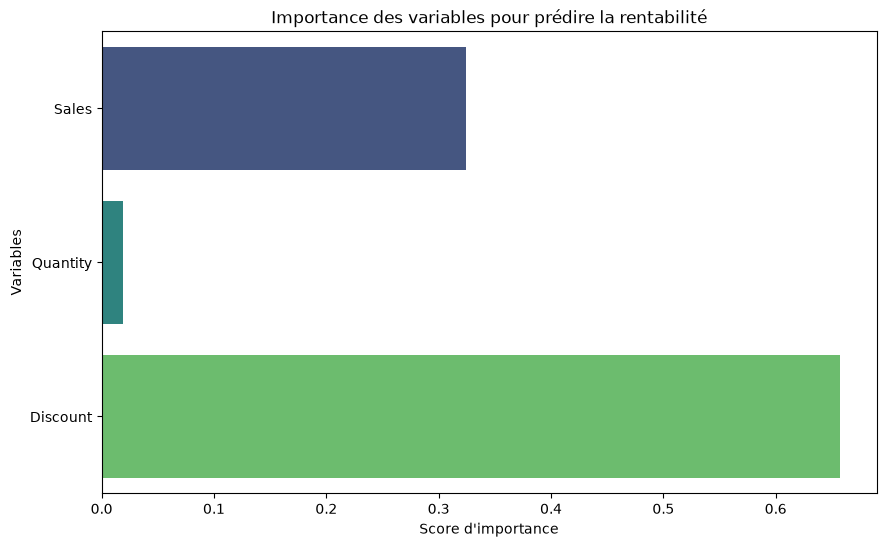

In [15]:
# 1. Récupération de l'importance des variables depuis le modèle Random Forest
importances = model.feature_importances_
feature_names = features

# 2. Création d'un graphique à barres
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names, palette='viridis')
plt.title("Importance des variables pour prédire la rentabilité")
plt.xlabel("Score d'importance")
plt.ylabel("Variables")
plt.show()

La variable "Discount" (Remise) est la reine : Elle représente plus de 60 % de l'importance dans votre modèle. Cela signifie que pour savoir si une vente sera rentable ou non, le facteur n°1 est le niveau de remise accordé.

La variable "Sales" (Ventes) est importante : Elle arrive en deuxième position, ce qui est logique : une grosse vente impacte forcément le profit.

La variable "Quantity" (Quantité) est négligeable : Elle n'a quasiment aucun impact sur la prédiction de la rentabilité dans votre modèle.

Ce modèle montre que la rentabilité est extrêmement sensible à la stratégie de remise ('Discount'). Les décisions de réduction de prix ont un impact bien plus fort sur la rentabilité finale que le volume de produits vendus ('Quantity'). Cela suggère qu'une optimisation des politiques de remise serait le levier le plus efficace pour améliorer les marges de l'entreprise.